- **Dataset:** Social Media Sentiments Analysis Dataset 📊
- **Dataset Author:** Kashish Parmar
- **Source**: https://www.kaggle.com/datasets/kashishparmar02/social-media-sentiments-analysis-dataset
- **Questions to be Answered by Analysis:**
1. What are the average engagement trends over time (year/month/day/hour) per platform?
2. What are the average engagement trends per platform?
3. What are the top-performing posts per platform?
4. What is the relationship between post likes and retweets per platform?
5. What is the relationship between no. of hashtags a post has and engagement per platform?
6. What is the relationship between post length and engagement per platform?
7. Which are the trending hashtags per platform?
8. Which word(s) are posted most often per platform?
9. What are the sentiments often expressed across posts per platform?
10. What topics are often discussed per platform?
- **Audience of Analysis:** Social Media Advertisers

### Project Setup + Data Exploration

In [1]:
!pip install kagglehub

In [2]:
# Install Libraries
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from kagglehub import KaggleDatasetAdapter

In [3]:
# Code Courtesy of: Kashish Parmar

# Set path of chosen file
file_path = 'sentimentdataset.csv'

# Load the latest version of dataset
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  'kashishparmar02/social-media-sentiments-analysis-dataset',
  file_path,
)

# View 1st five rows
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [4]:
# View dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [5]:
# Drop unwanted columns
df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'Timestamp', 'User', 'Country'])

In [6]:
# View dataset descriptive details (except those of int64 data type)
df.describe(exclude=['I'])

,Text,Sentiment,Platform,Hashtags,Retweets,Likes,Year,Month,Day,Hour
count,732,732,732,732,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
unique,707,279,4,697,NaN,NaN,NaN,NaN,NaN,NaN
top,"A compassionate rain, tears of empathy fallin...",Positive,Instagram,#Compassionate #TearsOfEmpathy,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,44,258,3,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,NaN,NaN,NaN,NaN,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,NaN,NaN,NaN,NaN,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,NaN,NaN,NaN,NaN,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,NaN,NaN,NaN,NaN,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000


In [7]:
# View Remaining Columns
df.columns

Index(['Text', 'Sentiment', 'Platform', 'Hashtags', 'Retweets', 'Likes',
       'Year', 'Month', 'Day', 'Hour'],
      dtype='object')

In [8]:
# Strip Whitespace from Platform Names (to avoid duplicate results)
df['Platform'] = df['Platform'].str.strip()

In [9]:
# Count of Posts Per Platform
post_count = df['Platform'].value_counts()

# Calculate Percentage of Posts Per Platform
post_percentage = (
    df['Platform'].value_counts(normalize=True) * 100
)

# Create Table With Counts and Percentages
platform_summary = pd.DataFrame({
    'Number_of_Posts': post_count,
    'Percentage': post_percentage
})

# Round Percentages to 2 Decimal Places
platform_summary['Percentage'] = (
    platform_summary['Percentage'].round(2)
)

# Display Table
display(platform_summary)

,Number_of_Posts,Percentage
Platform,,
Instagram,258,35.25
Twitter,243,33.20
Facebook,231,31.56


***Interpretation:*** Instagram posts represent the greatest portion of posts, an approximate 35% share of the dataset. There is however only a small difference between this platform and the others. For Twitter, there was a difference of 15 posts (2.05% less) and for Facebook, a difference of 27 posts (3.69% less). Social media advertisers could use this information an indication of the popularity of each platform, therefore determine the viability of publishling ads to each platform for optimal viwership.

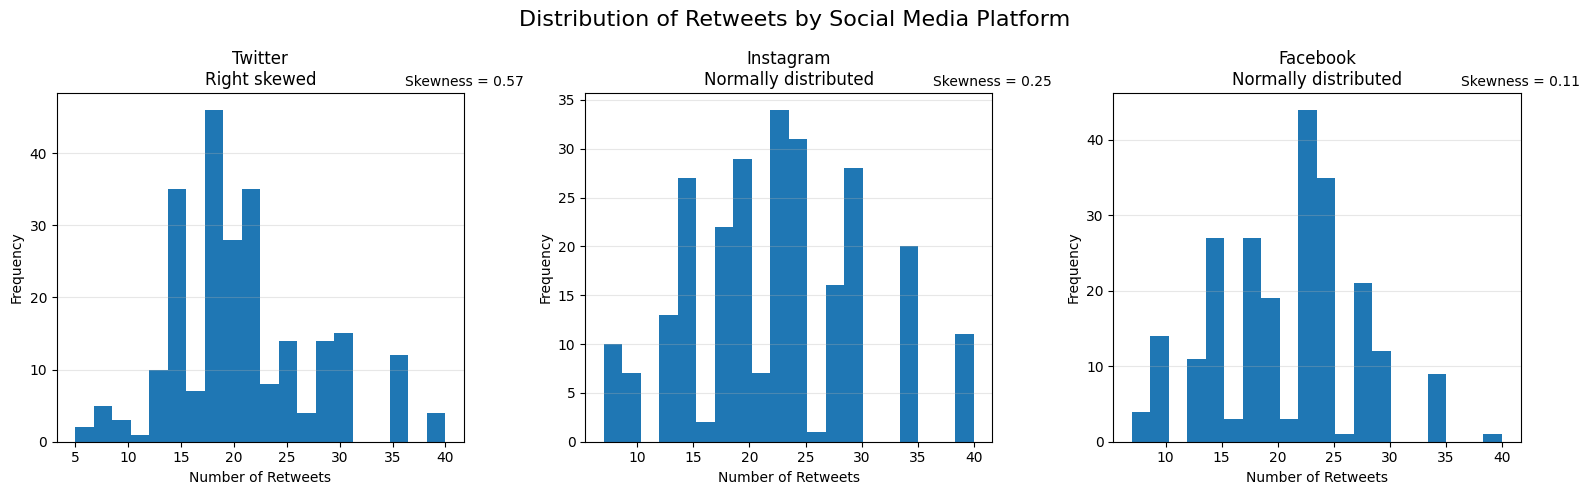

In [10]:
# Distribution of Retweets Per Platform

from scipy.stats import skew

# Get the different platforms
platforms = df['Platform'].dropna().unique()

# Create the subplots
fig, axes = plt.subplots(
    1,
    len(platforms),
    figsize=(16, 5)
)

# Make axes iterable if there is only one platform
if len(platforms) == 1:
    axes = [axes]

# Create a histogram for each platform
for i, platform in enumerate(platforms):

    # Select retweets for the current platform
    platform_data = df[
        df['Platform'] == platform
    ]['Retweets'].dropna()

    # Calculate skewness
    skewness = skew(platform_data)

    # Classify the distribution
    if -0.5 <= skewness <= 0.5:
        distribution = 'Normally distributed'
    elif skewness < -0.5:
        distribution = 'Left skewed'
    else:
        distribution = 'Right skewed'

    # Create histogram
    axes[i].hist(
        platform_data,
        bins=20
    )

    # Add title
    axes[i].set_title(
        f'{platform}\n{distribution}'
    )

    # Add axis labels
    axes[i].set_xlabel('Number of Retweets')
    axes[i].set_ylabel('Frequency')

    # Add grid
    axes[i].grid(
        axis='y',
        alpha=0.3
    )

    # Add skewness value above histogram
    axes[i].text(
        1,
        1.02,
        f'Skewness = {skewness:.2f}',
        transform=axes[i].transAxes,
        ha='center',
        fontsize=10
    )

# Overall title
fig.suptitle(
    'Distribution of Retweets by Social Media Platform',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [11]:
# Calculate Median Retweets for Twitter only
median_retweet = (
    df[df['Platform'] == 'Twitter']
    .groupby('Platform')['Retweets']
    .median()
    .sort_values(ascending=False)
)

display(median_retweet)

Platform
Twitter    20.0
Name: Retweets, dtype: float64

In [12]:
# Calculate Mean Retweets for Instagram and Facebook only
mean_retweet = (
    df[df['Platform'].isin(['Instagram', 'Facebook'])]
    .groupby('Platform')['Retweets']
    .mean()
    .sort_values(ascending=False)
)

display(mean_retweet)

Platform
Instagram    22.600775
Facebook     20.969697
Name: Retweets, dtype: float64

***Interpretation:*** The distribution of Twitter's retweet data suggests skewness. Hence, the median retweets will act as a reliable estimator of the retweets per post (20 retweets). Conversely, Instagram's and Facebook's retweet data are normally distributed; hence the mean retweets will act as a reliable estimator of the retweets per platform (Instagram ≈ 23 retweets | Facebook ≈ 21 retweets). Social media advertisers may use this data to anticipate the number of retweets their posts could attract on each platform, given these have similar characteristics to the posts in the dataset.

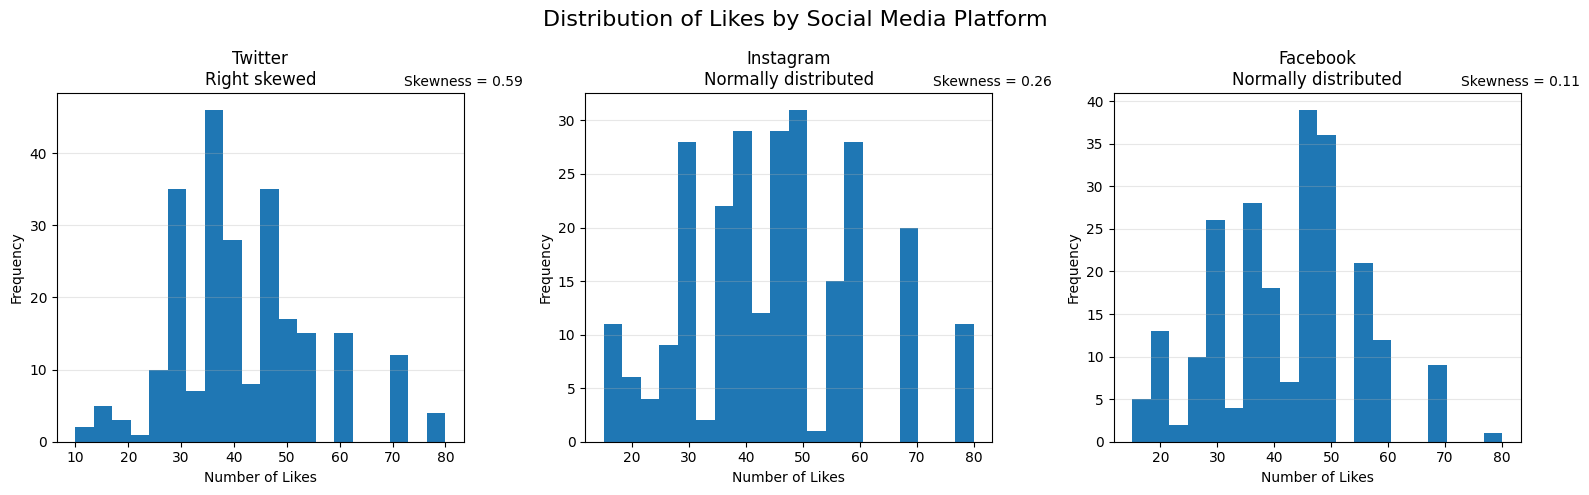

In [13]:
# Distribution of Likes Per Platform

# Get the different platforms
platforms = df['Platform'].dropna().unique()

# Create the subplots
fig, axes = plt.subplots(
    1,
    len(platforms),
    figsize=(16, 5)
)

# Make axes iterable if there is only one platform
if len(platforms) == 1:
    axes = [axes]

# Create a histogram for each platform
for i, platform in enumerate(platforms):

    # Select retweets for the current platform
    platform_data = df[
        df['Platform'] == platform
    ]['Likes'].dropna()

    # Calculate skewness
    skewness = skew(platform_data)

    # Classify the distribution
    if -0.5 <= skewness <= 0.5:
        distribution = 'Normally distributed'
    elif skewness < -0.5:
        distribution = 'Left skewed'
    else:
        distribution = 'Right skewed'

    # Create histogram
    axes[i].hist(
        platform_data,
        bins=20
    )

    # Add title
    axes[i].set_title(
        f'{platform}\n{distribution}'
    )

    # Add axis labels
    axes[i].set_xlabel('Number of Likes')
    axes[i].set_ylabel('Frequency')

    # Add grid
    axes[i].grid(
        axis='y',
        alpha=0.3
    )

    # Add skewness value above histogram
    axes[i].text(
        1,
        1.02,
        f'Skewness = {skewness:.2f}',
        transform=axes[i].transAxes,
        ha='center',
        fontsize=10
    )

# Overall title
fig.suptitle(
    'Distribution of Likes by Social Media Platform',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [14]:
# Calculate Median Likes for Twitter only
median_likes = (
    df[df['Platform'] == 'Twitter']
    .groupby('Platform')['Likes']
    .median()
    .sort_values(ascending=False)
)

display(median_likes)

Platform
Twitter    40.0
Name: Likes, dtype: float64

In [15]:
# Calculate Mean Retweets for Instagram and Facebook only
mean_likes = (
    df[df['Platform'].isin(['Instagram', 'Facebook'])]
    .groupby('Platform')['Likes']
    .mean()
    .sort_values(ascending=False)
)

display(mean_likes)

Platform
Instagram    45.089147
Facebook     41.870130
Name: Likes, dtype: float64

***Interpretation:*** The distribution of Twitter's likes data suggests skewness. Hence, the median likes will act as a reliable estimator of the likes per post (40 likes). Conversely, Instagram's and Facebook's likes data are normally distributed; hence the mean likes will act as a reliable estimator of the likes per post (Instagram ≈ 45 likes | Facebook ≈ 42 likes). Based on this data, social media advertisers may also anticipate that their posts could attract similar likes on each platform given these have similar characteristics to the posts in the dataset.

### Engagement Per Platform

In [16]:
# Calculate Engagement Levels
df['Engagement'] = (
    df['Retweets'] +
    df['Likes']
)

In [17]:
# Check Engagement Calculation
df[['Platform', 'Retweets', 'Likes', 'Engagement']].head(10)

,Platform,Retweets,Likes,Engagement
0,Twitter,15.0,30.0,45.0
1,Twitter,5.0,10.0,15.0
2,Instagram,20.0,40.0,60.0
3,Facebook,8.0,15.0,23.0
4,Instagram,12.0,25.0,37.0
5,Twitter,25.0,50.0,75.0
6,Facebook,10.0,20.0,30.0
7,Instagram,15.0,30.0,45.0
8,Twitter,30.0,60.0,90.0
9,Facebook,18.0,35.0,53.0


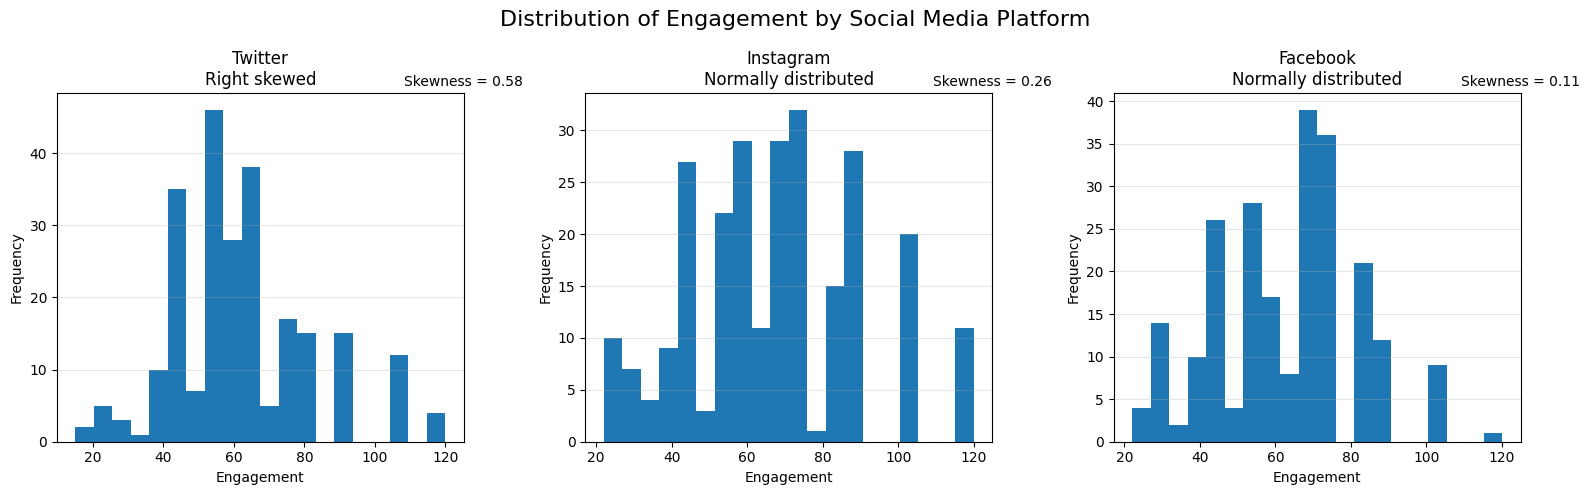

In [18]:
# Distribution of Engagement Per Platform

# Get the different platforms
platforms = df['Platform'].dropna().unique()

# Create the subplots
fig, axes = plt.subplots(
    1,
    len(platforms),
    figsize=(16, 5)
)

# Make axes iterable if there is only one platform
if len(platforms) == 1:
    axes = [axes]

# Create a histogram for each platform
for i, platform in enumerate(platforms):

    # Select retweets for the current platform
    platform_data = df[
        df['Platform'] == platform
    ]['Engagement'].dropna()

    # Calculate skewness
    skewness = skew(platform_data)

    # Classify the distribution
    if -0.5 <= skewness <= 0.5:
        distribution = 'Normally distributed'
    elif skewness < -0.5:
        distribution = 'Left skewed'
    else:
        distribution = 'Right skewed'

    # Create histogram
    axes[i].hist(
        platform_data,
        bins=20
    )

    # Add title
    axes[i].set_title(
        f'{platform}\n{distribution}'
    )

    # Add axis labels
    axes[i].set_xlabel('Engagement')
    axes[i].set_ylabel('Frequency')

    # Add grid
    axes[i].grid(
        axis='y',
        alpha=0.3
    )

    # Add skewness value above histogram
    axes[i].text(
        1,
        1.02,
        f'Skewness = {skewness:.2f}',
        transform=axes[i].transAxes,
        ha='center',
        fontsize=10
    )

# Overall title
fig.suptitle(
    'Distribution of Engagement by Social Media Platform',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [19]:
# Calculate Median Engagement for Twitter only
median_engagement = (
    df[df['Platform'] == 'Twitter']
    .groupby('Platform')['Engagement']
    .median()
    .sort_values(ascending=False)
)

display(median_engagement)

Platform
Twitter    60.0
Name: Engagement, dtype: float64

In [20]:
# Calculate Mean Engagement for Instagram and Facebook only
mean_engagement = (
    df[df['Platform'].isin(['Instagram', 'Facebook'])]
    .groupby('Platform')['Engagement']
    .mean()
    .sort_values(ascending=False)
)

display(mean_engagement)

Platform
Instagram    67.689922
Facebook     62.839827
Name: Engagement, dtype: float64

***Interpretation:*** The distribution of Twitter's engagement data suggests skewness. Hence, the median engagement will act as a reliable estimator of the engagement per post (60 units). Conversely, Instagram's and Facebook's engagement data are normally distributed; hence the mean engagement will act as a reliable estimator of the engagement per post (Instagram ≈ 68 units | Facebook ≈ 63 units). Social media advertisers may then anticipate that their posts could attract similar engagement on each platform given these have similar characteristics to the posts in the dataset.

In [21]:
# Calculate Total Engagement Per Platform
engagement_summary = (
    df.groupby('Platform')['Engagement']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Display Results
display(engagement_summary)

,Platform,Engagement
0,Instagram,17464.0
1,Twitter,15168.0
2,Facebook,14516.0


***Interpretation:*** Instagram had the highest engagement. It can then be inferred that this platform is the most viable for any advertising efforts; however, Twitter and Instagram are also viable given their engagement are only 2296 and 2948 units less than that of Instagram.  

In [22]:
# Median Engagement By Year & Platform
yearly_median = (
    df.groupby(['Year', 'Platform'])['Engagement']
      .median()
      .reset_index(name='Median_Engagement')
)

display(yearly_median.head())

,Year,Platform,Median_Engagement
0,2010,Twitter,90.0
1,2011,Facebook,71.0
2,2011,Instagram,67.0
3,2012,Facebook,45.0
4,2012,Instagram,90.0


In [23]:
# Median Engagement By Month and Platform
monthly_median = (
    df.groupby(
        ['Month', 'Platform']
    )['Engagement']
    .median()
    .reset_index(name='Median_Engagement')
)

display(monthly_median.head())

,Month,Platform,Median_Engagement
0,1,Facebook,45.0
1,1,Instagram,53.0
2,1,Twitter,57.0
3,2,Facebook,67.0
4,2,Instagram,75.0


In [24]:
# Median Engagement By Day and Platform
daily_median = (
    df.groupby(
        ['Month', 'Day', 'Platform']
    )['Engagement']
    .median()
    .reset_index(name='Median_Engagement')
)

display(daily_median.head())

,Month,Day,Platform,Median_Engagement
0,1,5,Instagram,39.0
1,1,5,Twitter,69.0
2,1,7,Instagram,45.0
3,1,7,Twitter,49.5
4,1,8,Facebook,105.0


In [25]:
# Median Engagement By Hour and Platform
hourly_median = (
    df.groupby(
        ['Hour', 'Platform']
    )['Engagement']
    .median()
    .reset_index(name='Median_Engagement')
)

display(hourly_median.head())

,Hour,Platform,Median_Engagement
0,0,Twitter,53.0
1,2,Facebook,54.0
2,3,Facebook,54.0
3,3,Twitter,54.0
4,5,Facebook,83.0


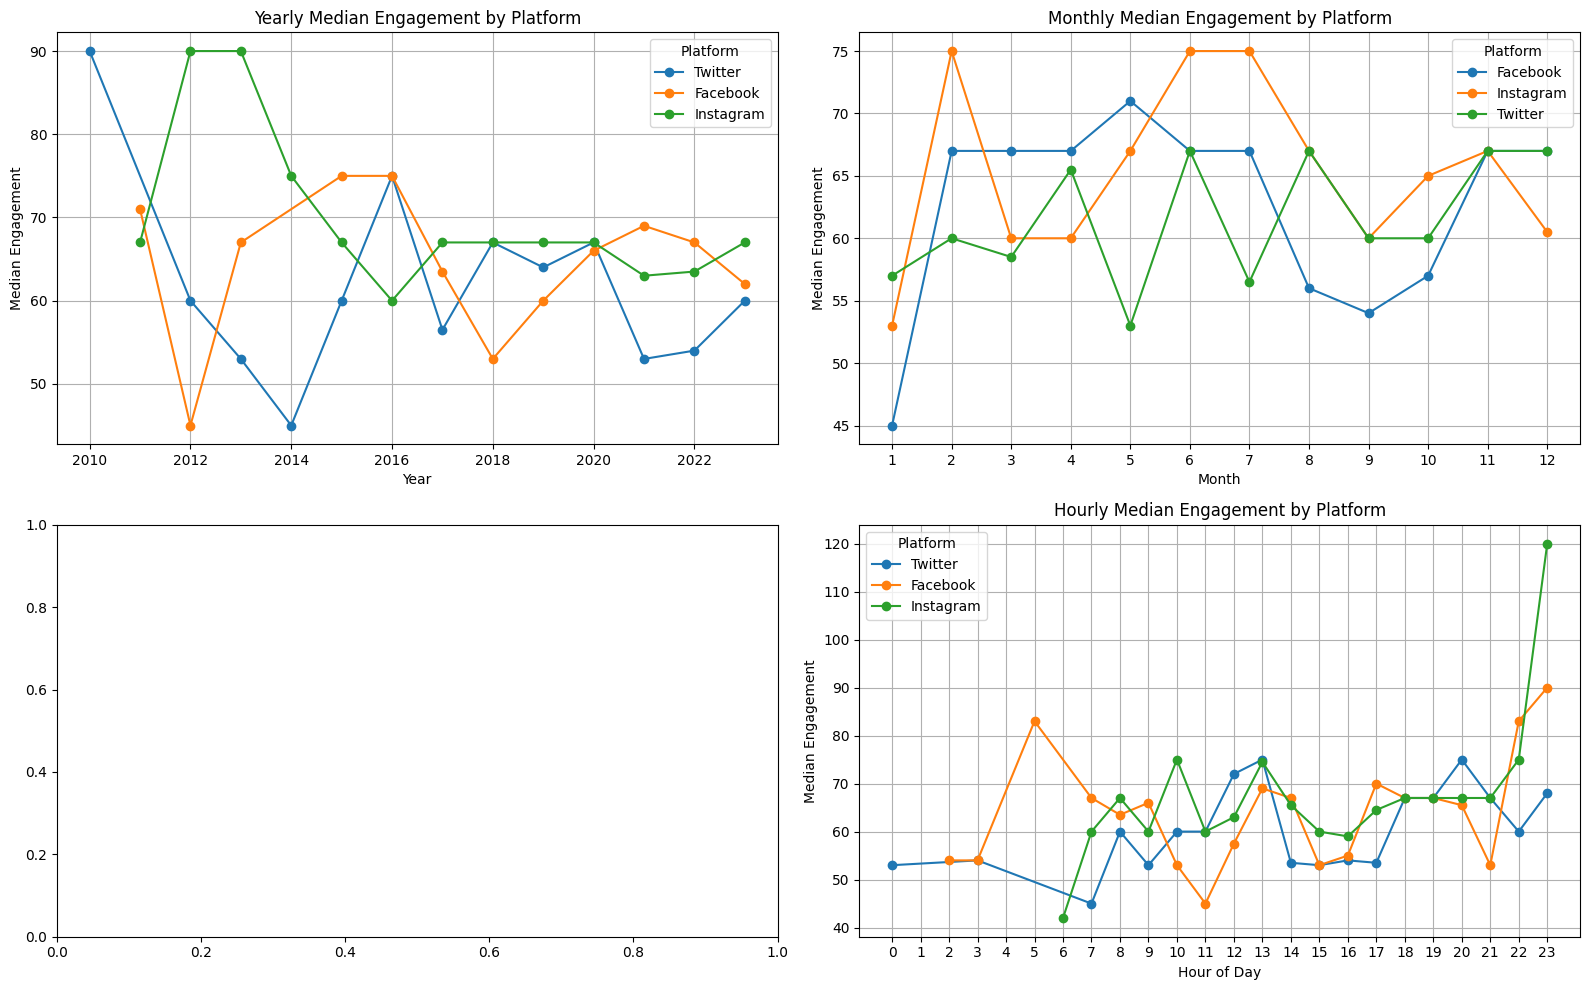

In [26]:
# Line Plots of Yearly, Monthly and Hourly Engagement Per Platform

# Create Plots (2 × 2)
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

# Subplot 1: Yearly Median Engagement
for platform in yearly_median['Platform'].unique():

    data = yearly_median[
        yearly_median['Platform'] == platform
    ]

    axes[0, 0].plot(
        data['Year'],
        data['Median_Engagement'],
        marker='o',
        label=platform
    )

axes[0, 0].set_title(
    'Yearly Median Engagement by Platform'
)

axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Median Engagement')

axes[0, 0].legend(
    title='Platform'
)

axes[0, 0].grid(True)

# Subplot 2: Monthly Median Engagement (Year Excluded)
for platform in monthly_median['Platform'].unique():

    data = monthly_median[
        monthly_median['Platform'] == platform
    ]

    axes[0, 1].plot(
        data['Month'],
        data['Median_Engagement'],
        marker='o',
        label=platform
    )

axes[0, 1].set_title(
    'Monthly Median Engagement by Platform'
)

axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Median Engagement')

axes[0, 1].set_xticks(range(1, 13))

axes[0, 1].legend(
    title='Platform'
)

axes[0, 1].grid(True)

'''
# Subplot 3: Daily Median Engagement (Year + Month Excluded)

# Create Month-Day label
daily_median['Month_Day'] = (
    daily_median['Month'].astype(str).str.zfill(2)
    + '-'
    + daily_median['Day'].astype(str).str.zfill(2)
)

for platform in daily_median['Platform'].unique():

    data = daily_median[
        daily_median['Platform'] == platform
    ]

    axes[1, 0].plot(
        data['Month_Day'],
        data['Median_Engagement'],
        marker='o',
        label=platform
    )

axes[1, 0].set_title('Daily Median Engagement by Platform')
axes[1, 0].set_xlabel('Month-Day')
axes[1, 0].set_ylabel('Median Engagement')

axes[1, 0].set_xticks(range(1, 32))

axes[1, 0].legend(
    title='Platform'
)

axes[1, 0].grid(True)
'''

# Subplot 4: Hourly Median Engagement
for platform in hourly_median['Platform'].unique():

    data = hourly_median[
        hourly_median['Platform'] == platform
    ]

    axes[1, 1].plot(
        data['Hour'],
        data['Median_Engagement'],
        marker='o',
        label=platform
    )

axes[1, 1].set_title(
    'Hourly Median Engagement by Platform'
)

axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Median Engagement')

axes[1, 1].set_xticks(range(0, 24))

axes[1, 1].legend(
    title='Platform'
)

axes[1, 1].grid(True)

# Adjust Layout
plt.tight_layout()

plt.show()

***Interpretation:*** 
- Yearly Median Engagement (2010-2023):
    - Twitter: Its median engagement was 90 units in 2010 then 60 units in 2023, representing a 30 unit decline excluding fluctuations. Moreover, its highest engagement was in 2010 (60 units) and lowest in 2014 (53 units approx.).
    - Facebook: Its median engagement was 71 units approx. in 2011 then 62 units approx. in 2023, representing a 9 unit decline excluding fluctuations. Also, its highest engagement was in 2015 and 2016 (75 units approx.) and lowest in 2012 (45 units approx.).
    - Instagram: Its median engagement was 67 units approx. in 2011 and the same in 2023, representing a 0 unit decline excluding fluctuations. Furthermore, its highest engagement was in 2012 and 2013 (90 units) and lowest in 2016 (60 units).
    - *Of all 3 platforms, Instagram appears to have the best potential for sustainable advertising yearly given it had a 0 unit decline between its first and last engagement.*   
- Monthly Median Engagement (January to December):
    - Twitter: Its median engagement transitioned from 57 units approx. in January to 67 units approx. in December - a 10 unit increase excluding fluctuations. Its highest engagement was in June, August, November and December (67 units approx.) and its lowest in May (53 units approx.).
    - Facebook: Its engagement transitioned from 45 units approx. in January to 67 units approx. in December - a 22 unit increase excluding fluctuations. Its highest engagement was in May (71 units approx.) and its lowest in January (45 units approx.).
    - Instagram: Its engagement transitioned from 53 units approx. in January to 61 units approx. in December - a 8 unit increase excluding fluctuations. Its highest engagement was in February, June, and July (75 units) and its lowest in January (53 units approx.).
    - *Of all 3 platforms, Facebook appears to have the best potential for sustainable advertising monthly given it had a 22 unit increase between its first and last engagement.*   
- Daily Median Engagement (Midnight-11pm):
    - Twitter had its peak median engagement at 1pm and 8pm daily.
    - Facebook had its peak median engagement at 11pm daily.
    - Instagram had its peak median engagement at 10am and 1pm daily.
    - *Considering the peak hours for each platform, social media advertisers can push ads more frequently at these times to improve their audience reach.*

In [27]:
# Top-Performing Post Per Platform
top_posts = (
    df.loc[
        df.groupby('Platform')['Engagement'].idxmax(),
        ['Platform', 'Text', 'Engagement']
    ]
    .sort_values('Engagement', ascending=False)
    .reset_index(drop=True)
)

display(top_posts)

,Platform,Text,Engagement
0,Facebook,Motivated to achieve fitness goals after an in...,120.0
1,Instagram,Thrilled to witness the grandeur of a cultural...,120.0
2,Twitter,Anticipation for an upcoming adventure in an e...,120.0


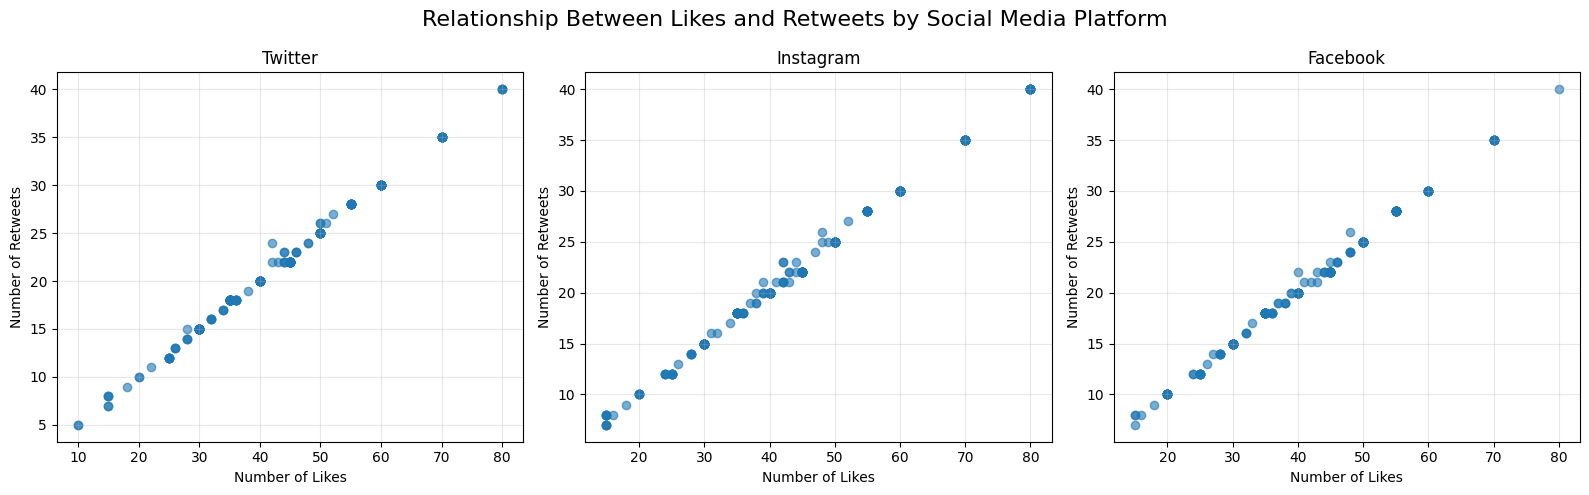

In [28]:
# Scatterplot of Likes vs Retweets Per Platform

# Get the different platforms
platforms = df['Platform'].unique()

# Create subplots
fig, axes = plt.subplots(
    1,
    len(platforms),
    figsize=(16, 5)
)

# Handle the situation where there is only one platform
if len(platforms) == 1:
    axes = [axes]

# Create a scatter plot for each platform
for i, platform in enumerate(platforms):

    data = df[
        df['Platform'] == platform
    ]

    axes[i].scatter(
        data['Likes'],
        data['Retweets'],
        alpha=0.6
    )

    axes[i].set_title(
        f'{platform}'
    )

    axes[i].set_xlabel(
        'Number of Likes'
    )

    axes[i].set_ylabel(
        'Number of Retweets'
    )

    axes[i].grid(True, alpha=0.3)

# Overall title
fig.suptitle(
    'Relationship Between Likes and Retweets by Social Media Platform',
    fontsize=16
)

plt.tight_layout()
plt.show()

***Interpretation:*** For each platform, a strong and positive relationship exists between the number of likes and retweets per post. This is indicated by the increasing (bottom-left to top-right) and tightly clustered trend of the data. Therefore, as a post gains likes it is likely to attract many retweets. This data can be used as a basis by social media advertisers of the retweets their posts could attract given the number of likes already received and their similarity to posts in the dataset.

In [29]:
# Calculate Post Length

# Count the number of words in each post
df['Post_Length'] = (
    df['Text']
    .apply(lambda x: len(str(x).split()))
)

# Display the results
display(
    df[['Text', 'Platform', 'Post_Length', 'Engagement']].head()
)

,Text,Platform,Post_Length,Engagement
0,Enjoying a beautiful day at the park! ...,Twitter,7,45.0
1,Traffic was terrible this morning. ...,Twitter,5,15.0
2,Just finished an amazing workout! 💪 ...,Instagram,6,60.0
3,Excited about the upcoming weekend getaway! ...,Facebook,6,23.0
4,Trying out a new recipe for dinner tonight. ...,Instagram,8,37.0


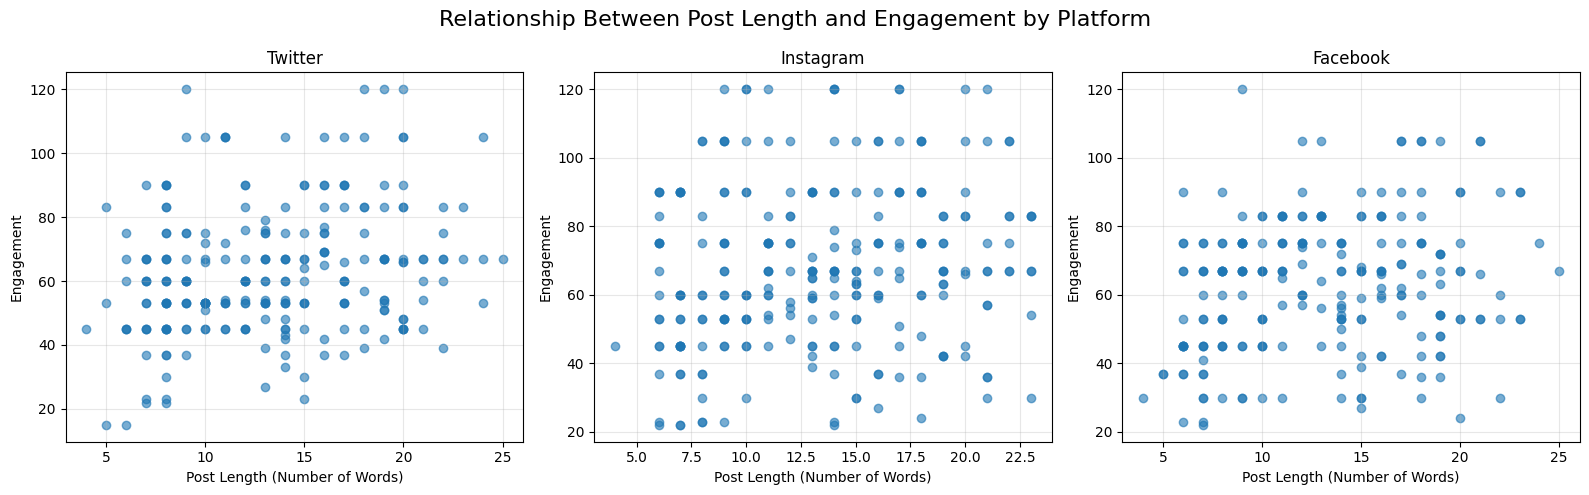

In [30]:
# Scatterplot of Post Length vs Engagement Per Platform

# Copy dataset
scatter_data = df.copy()

# Get the different platforms
platforms = scatter_data['Platform'].unique()

# Create one subplot for each platform
fig, axes = plt.subplots(
    1,
    len(platforms),
    figsize=(16, 5)
)

# Handle the case where there is only one platform
if len(platforms) == 1:
    axes = [axes]

# Create a scatter plot for each platform
for i, platform in enumerate(platforms):

    data = scatter_data[
        scatter_data['Platform'] == platform
    ]

    axes[i].scatter(
        data['Post_Length'],
        data['Engagement'],
        alpha=0.6
    )

    axes[i].set_title(
        f'{platform}'
    )

    axes[i].set_xlabel(
        'Post Length (Number of Words)'
    )

    axes[i].set_ylabel(
        'Engagement'
    )

    axes[i].grid(
        True,
        alpha=0.3
    )

# Overall title
fig.suptitle(
    'Relationship Between Post Length and Engagement by Platform',
    fontsize=16
)

plt.tight_layout()
plt.show()

***Interpretation:*** As the points are scattered with no discernable pattern, no relationship exists between post length and engagement received per platform. Hence, this data does not support the hypothesis that lengthier ad posts by social media advertisers will drive more engagement (likes + retweets) by their audience.

In [31]:
# Hashtag Count Per Post

# Count the number of hashtags in each post
df['Hashtag_Count'] = (
    df['Hashtags']
    .apply(lambda x: len(str(x).split()))
)

# Display the first few rows
display(
    df[['Text', 'Platform', 'Hashtags', 'Hashtag_Count', 'Engagement']].head()
)

,Text,Platform,Hashtags,Hashtag_Count,Engagement
0,Enjoying a beautiful day at the park! ...,Twitter,#Nature #Park,2,45.0
1,Traffic was terrible this morning. ...,Twitter,#Traffic #Morning,2,15.0
2,Just finished an amazing workout! 💪 ...,Instagram,#Fitness #Workout,2,60.0
3,Excited about the upcoming weekend getaway! ...,Facebook,#Travel #Adventure,2,23.0
4,Trying out a new recipe for dinner tonight. ...,Instagram,#Cooking #Food,2,37.0


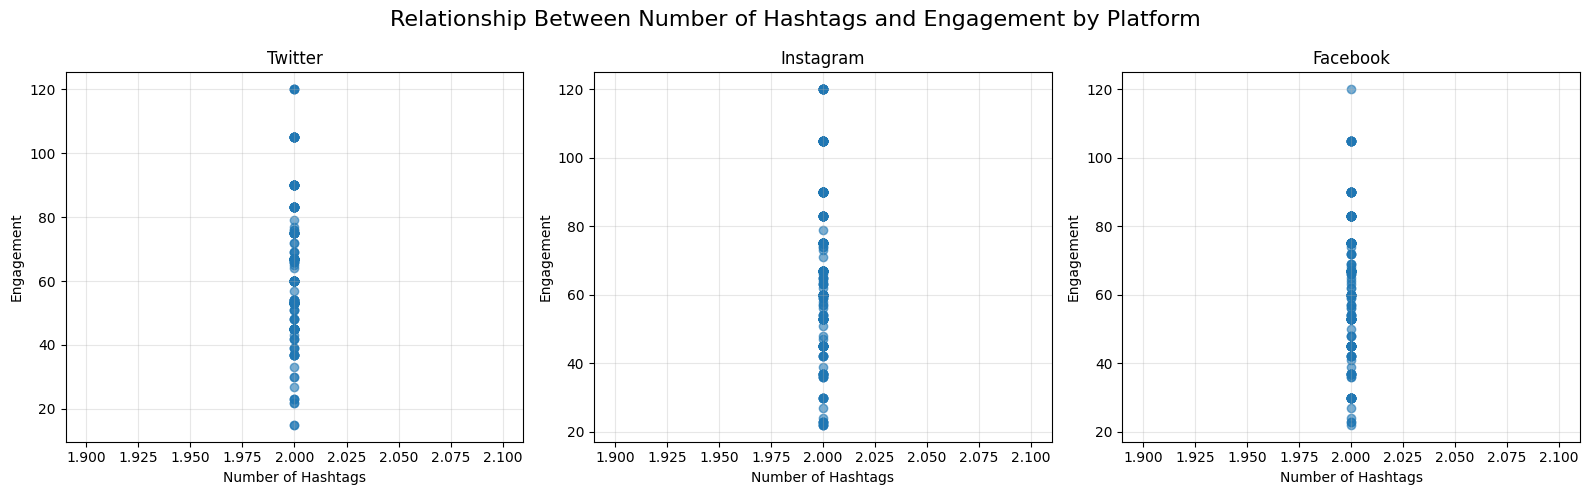

In [32]:
# Scatter Plot of Hashtag Count Vs Engagement Per Platform

# Get the different platforms
platforms = df['Platform'].unique()

# Create one subplot for each platform
fig, axes = plt.subplots(
    1,
    len(platforms),
    figsize=(16, 5)
)

# Handle the case where there is only one platform
if len(platforms) == 1:
    axes = [axes]

# Create a scatter plot for each platform
for i, platform in enumerate(platforms):

    data = df[
        df['Platform'] == platform
    ]

    axes[i].scatter(
        data['Hashtag_Count'],
        data['Engagement'],
        alpha=0.6
    )

    axes[i].set_title(
        f'{platform}'
    )

    axes[i].set_xlabel(
        'Number of Hashtags'
    )

    axes[i].set_ylabel(
        'Engagement'
    )

    axes[i].grid(
        True,
        alpha=0.3
    )

# Overall title
fig.suptitle(
    'Relationship Between Number of Hashtags and Engagement by Platform',
    fontsize=16
)

plt.tight_layout()
plt.show()

***Interpretation:*** The scatterplots above indicate that no direct relationship exists between number of hashtags and engagement per post. This is due to a limitation in the data, where posts have the same number of hashtags throughout the dataset (2 hashtags). Therefore, this data cannot be used by social media advertisers in determining engagement based on the total hashtags in their ad posts.

In [33]:
# Most Popular Hashtags By Platform

# Import Additional Library
import re

# Empty list to store the hashtag information
hashtag_data = []

# Iterate through each post in the dataset
for _, row in df.iterrows():

    platform = row['Platform']
    hashtags = str(row['Hashtags'])

    # Find all hashtags in the post
    found_hashtags = re.findall(
        r'#\w+',
        hashtags
    )

    # Add each hashtag and its platform to the list
    for hashtag in found_hashtags:

        hashtag_data.append({
            'Platform': platform,
            'Hashtag': hashtag.lower()
        })

# Convert the list into a DataFrame
hashtag_df = pd.DataFrame(hashtag_data)

# Count how many times each hashtag appears on each platform
hashtag_counts = (
    hashtag_df
    .groupby(['Platform', 'Hashtag'])
    .size()
    .reset_index(name='Frequency')
)

# Sort from most popular to least popular
hashtag_counts = hashtag_counts.sort_values(
    ['Platform', 'Frequency'],
    ascending=[True, False]
)

display(hashtag_counts)

,Platform,Hashtag,Frequency
104,Facebook,#excitement,6
130,Facebook,#gratitude,6
132,Facebook,#grief,6
19,Facebook,#awe,5
63,Facebook,#contentment,5
...,...,...,...
1162,Twitter,#winterwarmth,1
1163,Twitter,#wistfulheart,1
1164,Twitter,#wonderfulmoment,1
1165,Twitter,#wonderment,1


In [34]:
# Top 5 Hashtags Per Platform

top_5_hashtags = (
    hashtag_counts
    .groupby('Platform')
    .head()
    .reset_index(drop=True)
)

display(top_5_hashtags)

,Platform,Hashtag,Frequency
0,Facebook,#excitement,6
1,Facebook,#gratitude,6
2,Facebook,#grief,6
3,Facebook,#awe,5
4,Facebook,#contentment,5
5,Instagram,#curiosity,5
6,Instagram,#confusion,4
7,Instagram,#despair,4
8,Instagram,#enthusiasm,4
9,Instagram,#euphoria,4


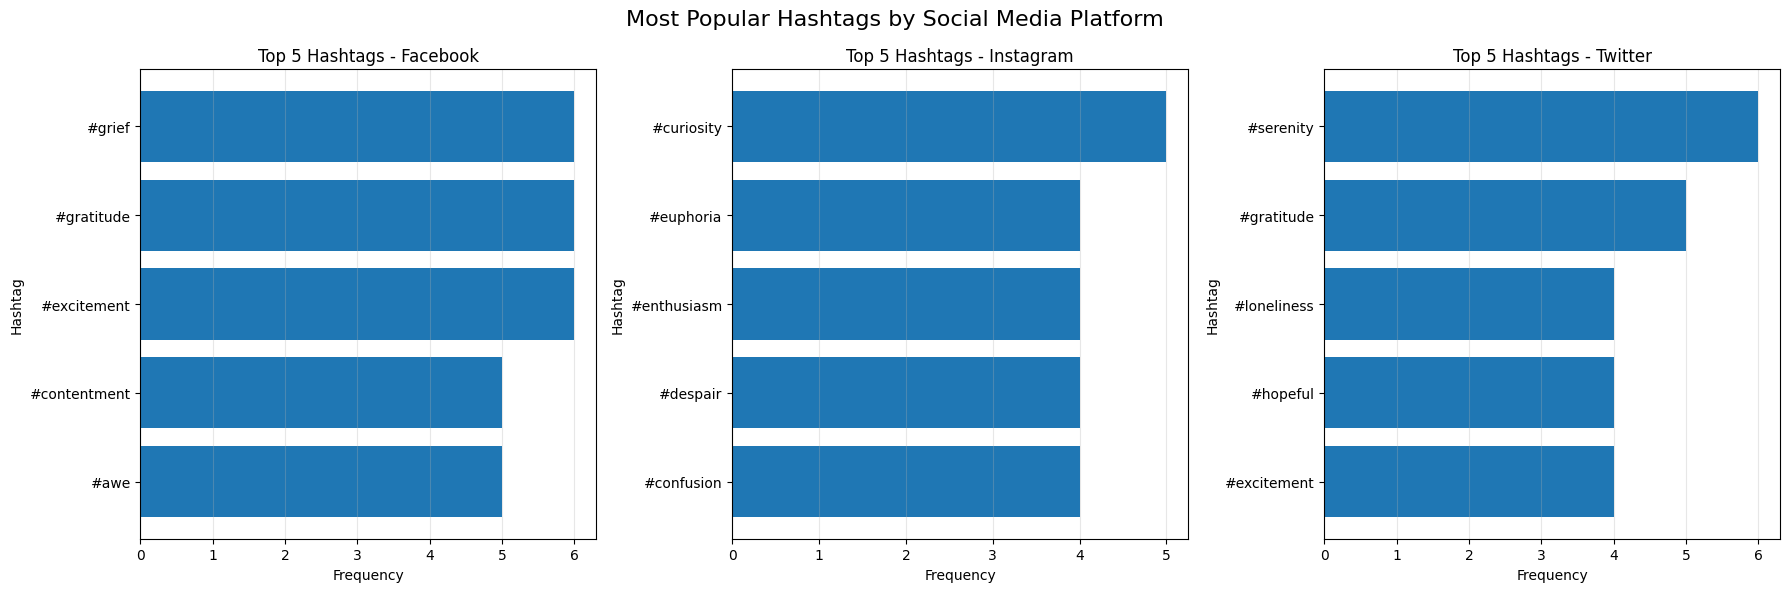

In [35]:
# Bar Chart of Top 5 Hashtags Per Platform

# Get the different platforms
platforms = top_5_hashtags['Platform'].unique()

# Create a subplot for each platform
fig, axes = plt.subplots(
    1,
    len(platforms),
    figsize=(18, 6)
)

# Handle the case where there is only one platform
if len(platforms) == 1:
    axes = [axes]

# Iterate through the platforms
for i, platform in enumerate(platforms):

    data = top_5_hashtags[
        top_5_hashtags['Platform'] == platform
    ].sort_values('Frequency')

    axes[i].barh(
        data['Hashtag'],
        data['Frequency']
    )

    axes[i].set_title(
        f'Top 5 Hashtags - {platform}'
    )

    axes[i].set_xlabel(
        'Frequency'
    )

    axes[i].set_ylabel(
        'Hashtag'
    )

    axes[i].grid(
        axis='x',
        alpha=0.3
    )

# Overall Title
fig.suptitle(
    'Most Popular Hashtags by Social Media Platform',
    fontsize=16
)

# Adjust Layout
plt.tight_layout()
plt.show()

***Interpretation*** The top 5 hashtags per platform are as follows:
- Facebook: #excitement, #gratitude, #grief, #awe, #contentment 
- Instagram: #confusion	, #despair, #enthusiasm, #euphoria, #hopeful
- Twitter: #serenity, #gratitude, #excitement, #hopeful, #loneliness

From an overview, the hashtags for each platform suggest more positive emotions than negative. Thus, it can be inferred that majority of the posts in the dataset express positive sentiment. Also, social media advertisers could adopt these hashtags in their posts to drive higher engagement.

In [36]:
# Identify High Engagement Posts Per Platform

# Create a new column to identify highly engaging posts
df['High_Engagement'] = False

# Process each platform separately
for platform in df['Platform'].dropna().unique():
    
    # Select posts from the current platform
    platform_data = df[df['Platform'] == platform]
    
    # Calculate the 75th percentile of engagement
    engagement_cutoff = platform_data['Engagement'].quantile(0.75)
    
    # Identify posts above the cutoff
    high_engagement_index = (
        platform_data['Engagement'] >= engagement_cutoff
    )
    
    # Mark these posts as highly engaging
    df.loc[
        platform_data.index[high_engagement_index],
        'High_Engagement'
    ] = True

In [37]:
# Count of High Engagement Posts Identified Per Platform
high_engagement_summary = (
    df[df['High_Engagement']]
    .groupby('Platform')
    .size()
    .reset_index(name='High_Engagement_Posts')
)

display(high_engagement_summary)

,Platform,High_Engagement_Posts
0,Facebook,74
1,Instagram,74
2,Twitter,63


***Interpretation:*** 
- Facebook and Instagram share the same number of high engagement posts (74). Alternatively, Twitter had 11 high engagement posts less than the other platforms. 
- The ratio of high engagement to low engagement posts per platform is as follows: 
    - Facebook: A 74:157 ratio or 32% high engagment posts. Given this low proportion, it suggests that very few engaging posts for this platform were captured in the dataset.
    - Instagram: A 37:92 (74:184) ratio or 28.7% high engagement posts. This low proportion also suggests that not many engaging posts forr this platform were captured in the dataset.
    - Twitter: A 7:20 (63:180) ratio or 25.9% high engagement posts. The low proportion can also suggest that very few engaging posts for this platform were captured in the dataset.

In [38]:
!pip install wordcloud

In [39]:
# Import Additional Libraries
from wordcloud import WordCloud
from collections import Counter

In [40]:
# Words To Be Excluded From the Word Cloud
stop_words = {
    'the', 'a', 'an', 'and', 'or', 'but', 'if', 'then',
    'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'to', 'of', 'in', 'on', 'for', 'with', 'at', 'by',
    'from', 'as', 'this', 'that', 'these', 'those',
    'it', 'its', 'i', 'you', 'he', 'she', 'we', 'they',
    'my', 'your', 'our', 'their', 'his', 'her', 's',
    'has', 'have', 'had', 'do', 'does', 'did', 'each',
    'will', 'would', 'can', 'could', 'should',
    'not', 'no', 'yes', 'so', 'than', 'too', 'very'
}

# Function to Clean Post Text
def clean_text(text):
    # Convert text to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove mentions such as @username
    text = re.sub(r'@\w+', '', text)
    
    # Remove the # symbol from hashtags
    text = re.sub(r'#', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Split the text into individual words
    words = text.split()
    
    # Remove stop words
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    return words

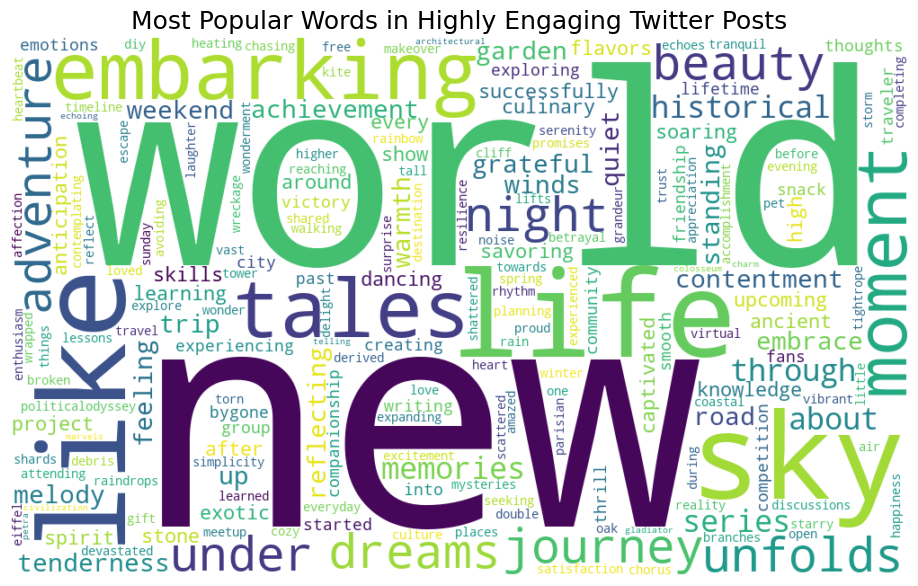

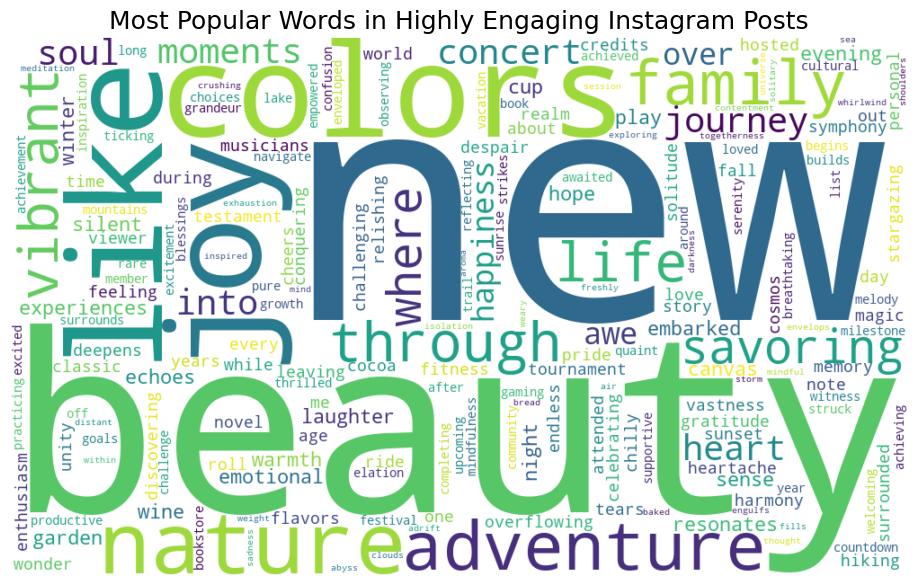

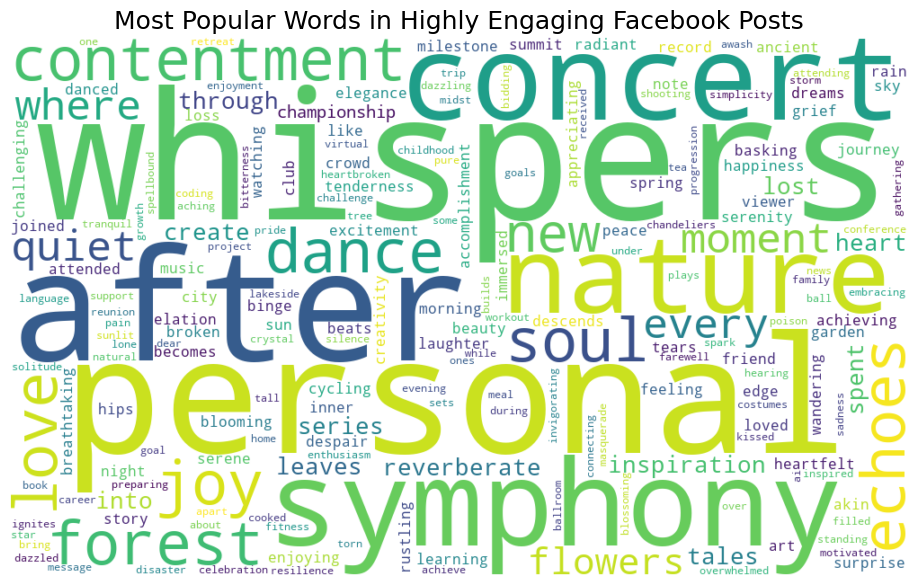

In [41]:
# Generate Word Cloud of High Engagement Posts Per Platform

# Get the different platforms
platforms = df['Platform'].dropna().unique()

for platform in platforms:
    
    # Select highly engaging posts for the current platform
    platform_data = df[
        (df['Platform'] == platform) &
        (df['High_Engagement'] == True)
    ]
    
    # Create an empty list to store words
    words = []
    
    # Clean and collect words from each post
    for text in platform_data['Text'].dropna():
        words.extend(clean_text(text))
    
    # Count how frequently each word occurs
    word_counts = Counter(words)
    
    # Create the word cloud
    wordcloud = WordCloud(
        width=1000,
        height=600,
        background_color='white'
    ).generate_from_frequencies(word_counts)
    
    # Display the word cloud
    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(
        f'Most Popular Words in Highly Engaging {platform} Posts',
        fontsize=18
    )
    plt.show()

In [42]:
# Display Words in High Engagement Posts Per Platform
for platform in platforms:
    
    # Select highly engaging posts
    platform_data = df[
        (df['Platform'] == platform) &
        (df['High_Engagement'] == True)
    ]
    
    # Collect words
    words = []
    
    for text in platform_data['Text'].dropna():
        words.extend(clean_text(text))
    
    # Count words
    word_counts = Counter(words)
    
    # Get the 10 most common words
    top_words = pd.DataFrame(
        word_counts.most_common(10),
        columns=['Word', 'Frequency']
    )
    
    print(f'\nTop 10 Words in Highly Engaging {platform} Posts')
    display(top_words)


Top 10 Words in Highly Engaging Twitter Posts


,Word,Frequency
0,new,7
1,world,5
2,life,4
3,sky,4
4,like,4
5,embarking,4
6,tales,4
7,moment,3
8,journey,3
9,under,3



Top 10 Words in Highly Engaging Instagram Posts


,Word,Frequency
0,new,6
1,beauty,6
2,colors,5
3,like,5
4,joy,5
5,nature,5
6,adventure,5
7,family,4
8,through,4
9,life,4



Top 10 Words in Highly Engaging Facebook Posts


,Word,Frequency
0,whispers,6
1,personal,5
2,after,5
3,symphony,5
4,concert,5
5,nature,4
6,contentment,4
7,forest,4
8,soul,4
9,dance,4


***Interpretation:*** 
- Of the 63 high engagement posts for Twitter, words like 'new', 'world', 'life', 'sky', 'like', 'embarking', 'tales', 'moment', 'journey' and 'under' occurred most often. 
- Of the 74 high engagement posts for Instagram, words like 'new', 'beauty', 'colors', 'like', 'joy', 'nature', 'adventure', 'family', 'through' and 'life' occurred most often.
- Of the 74 high engagement posts for Facebook, words like 'whispers', 'personal', 'after', 'symphony', 'concert', 'nature', 'contentment', 'forest', 'soul' and 'dance' occurred most often.

Similarly to the hashtags, social media advertisers may adopt these words in their ad posts to drive high engagement.

### Advanced Analysis

#### Sentiment Analysis via MultiNominal Naive Bayes Model

In [43]:
# Import Additional Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [44]:
# Check Sentiment Classes
print('Number of unique sentiment classes:')
print(df['Sentiment'].nunique())

print('\nNumber of posts in each sentiment class:')
print(df['Sentiment'].value_counts())

Number of unique sentiment classes:
279

Number of posts in each sentiment class:
Sentiment
Positive           44
Joy                42
Excitement         32
Neutral            14
Contentment        14
                   ..
Adrenaline          1
Harmony             1
ArtisticBurst       1
Radiance            1
Elegance            1
Name: count, Length: 279, dtype: int64


In [45]:
# Copy Dataset for Sentiment Analysis
df_sentiment = df.copy()

print('Number of posts for sentiment analysis:')
print(len(df_sentiment))

Number of posts for sentiment analysis:
732


In [46]:
# Exclude sentiment classes with few posts
sentiment_counts = df_sentiment['Sentiment'].value_counts()

valid_sentiments = sentiment_counts[
    sentiment_counts >= 42
].index

df_sentiment = df_sentiment[
    df_sentiment['Sentiment'].isin(valid_sentiments)
].copy()

print('Number of sentiment classes remaining:')
print(df_sentiment['Sentiment'].nunique())

print('\nPosts remaining:')
print(len(df_sentiment))

print('\nSentiment class distribution:')
print(df_sentiment['Sentiment'].value_counts())

Number of sentiment classes remaining:
2

Posts remaining:
86

Sentiment class distribution:
Sentiment
Positive      44
Joy           42
Name: count, dtype: int64


***Interpretation:*** Of the 732 posts in the dataset, 646 where dropped from the sentiment analysis as these had low posts per sentiment class (< 42 posts). This was done to ensure the model had ample data to learn from during training, to make reliable predictions for the test data and to improve the model accuracy. The model accuracy can best be improved by utilizing a more representative dataset for its training and testing - one which has almost equal amounts of each sentiment class for training the model.

In [47]:
# Function to Clean Text 
def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtag symbol
    text = re.sub(r'#', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


df_sentiment['Clean_Text'] = (
    df_sentiment['Text']
    .apply(clean_text)
)

display(
    df_sentiment[
        ['Text', 'Clean_Text', 'Sentiment']
    ].head()
)

,Text,Clean_Text,Sentiment
0,Enjoying a beautiful day at the park! ...,enjoying a beautiful day at the park,Positive
2,Just finished an amazing workout! 💪 ...,just finished an amazing workout,Positive
3,Excited about the upcoming weekend getaway! ...,excited about the upcoming weekend getaway,Positive
5,Feeling grateful for the little things in lif...,feeling grateful for the little things in life,Positive
6,Rainy days call for cozy blankets and hot coc...,rainy days call for cozy blankets and hot cocoa,Positive


In [48]:
# Create X and y
X = df_sentiment['Clean_Text']
y = df_sentiment['Sentiment']

print('Number of posts:', len(X))
print('Number of sentiment classes:', y.nunique())

Number of posts: 86
Number of sentiment classes: 2


***Interpretation:*** After excluding sentiment classes with low number of posts, only 86 posts and 2 sentiment classes were retained for the sentiment analysis. This is approximately 11.7% of the overall dataset.

In [49]:
# Check minimum number of posts per class
print('Smallest sentiment class:')
print(y.value_counts().min())

print('\nLargest sentiment class:')
print(y.value_counts().max())

Smallest sentiment class:
42

Largest sentiment class:
44


***Interpretation:*** The smallest sentiment class in the sentiment analysis had 42 posts while the largest had 44 posts. This is a small difference of 2.

In [50]:
# Split data - training & testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('Training posts:', len(X_train))
print('Testing posts:', len(X_test))

Training posts: 60
Testing posts: 26


***Interpretation:*** Of the 86 posts selected for the sentiment analysis, 60 (70%) were allotted to training the model while 26 (30%) were allotted to testing the same.

In [51]:
# Convert Text into TF-IDF Features
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print('Training feature matrix:', X_train_tfidf.shape)
print('Testing feature matrix:', X_test_tfidf.shape)

Training feature matrix: (60, 312)
Testing feature matrix: (26, 312)


In [52]:
# Create Model
nb_model = MultinomialNB()

In [53]:
# Train Model
nb_model.fit(
    X_train_tfidf,
    y_train
)

print('Naive Bayes model training completed.')

Naive Bayes model training completed.


In [54]:
# Make Predictions
y_pred = nb_model.predict(X_test_tfidf)

print('Predictions completed.')

Predictions completed.


In [55]:
# Determine Model Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f'Naive Bayes Accuracy: {accuracy:.2%}')

Naive Bayes Accuracy: 80.77%


***Interpretation:*** The model achieves a 80.77% accuracy, meaning it correctly identified the sentiment of approx. 81 posts accurately. Thus, the model can almost accurately classify new posts as 'Positive' or 'Joy'. Likewise, ad posts made by social media advertisers could almost accurately be classified as the same.

In [56]:
# Generate Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Joy        0.90      0.69      0.78        13
  Positive         0.75      0.92      0.83        13

    accuracy                           0.81        26
   macro avg       0.82      0.81      0.81        26
weighted avg       0.83      0.81      0.81        26



***Interpretation:***
- Precision:
    - Of the posts classified as 'Joy', 90% were classified correctly.
    - Of the posts classified as 'Positive', 75% were classified correctly.
- Recall (True Positive Rate):
    - Of the posts in the dataset actually classified as 'Joy', the model correctly predicted 69%.
    - Of all posts in the dataset actually classified as 'Positive', the model correctly predicted 92%.
- F1 Score:
    - The harmonic mean of precision and recall for 'Joy' classifications is 0.78. This value results from the closeness of its precision and recall values.
    - The harmonic mean of precision and recall for 'Positive' predictions is 0.83. This value results from the closeness of its precision and recall values.
- Support:
    - Of the 26 posts in the test set, there were 13 actual classifications of posts as 'Joy'.
    - Of the 26 posts in the test set, there were 13 actual classifications of posts as 'Positive'.
- Accuracy:
    - The model correctly classified 81% of the testing data.
- Macro Average:
    - The mean precision for each sentiment class regardless of their support is 0.82.
    - The mean recall for each sentiment class regardless of their support is 0.81.
    - The mean f1-score for each sentiment class regardless of their support is 0.81.  
    - The mean support for each sentiment class regardless of their support is 26.
- Weighted Average:
    - After calculating the mean precision for each sentiment class considering their support, the resulting value is 0.83.
    - After calculating the mean recall for each sentiment class considering their support, the resulting value is 0.81.
    - After calculating the mean f1-score for each sentiment class considering their support, the resulting value is 0.81.
    - After calculating the mean support for each sentiment class considering their support, the resulting value is 26.
- *The high model metrics suggest good model performance and can be used to almost correctly classify new posts as 'Joy' or 'Positive'. As such, posts made by social media advertisers of these sentiments could be correctly classified* 

In [57]:
# Calculate Macro & Weighted Averages
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

print(f'Macro Precision: {precision:.2%}')
print(f'Macro Recall: {recall:.2%}')
print(f'Macro F1-score: {f1_macro:.2%}')
print(f'Weighted F1-score: {f1_weighted:.2%}')

Macro Precision: 82.50%
Macro Recall: 80.77%
Macro F1-score: 80.51%
Weighted F1-score: 80.51%


In [58]:
# Create Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=nb_model.classes_
)

print('Confusion matrix shape:')
print(cm.shape)

Confusion matrix shape:
(2, 2)


<Figure size 1400x1200 with 0 Axes>

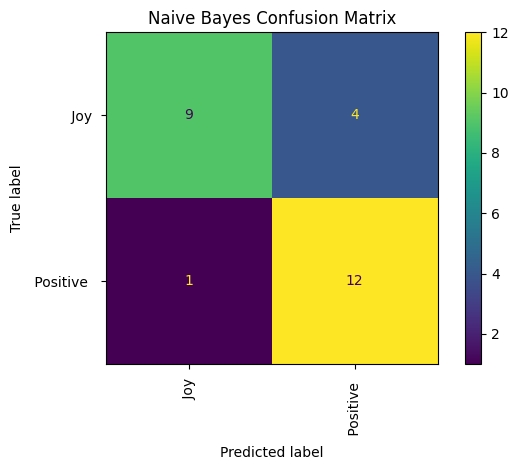

In [59]:
# Display Confusion Matrix
plt.figure(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot(
    xticks_rotation='vertical',
    values_format='d'
)

plt.title('Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.show()

***Interpretation:***
The model classified the posts from the test set as follows:
- True Positives: 9 for 'Joy' sentiment class | 12 for 'Positive' sentiment class
- False Positives: 4 for 'Joy' sentiment class | 1 for 'Positive' sentiment class

In [60]:
# Identify Most Frequently Confused Classes
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

incorrect_predictions = results[
    results['Actual'] != results['Predicted']
]

print('Number of incorrect predictions:')
print(len(incorrect_predictions))

display(
    incorrect_predictions.head(20)
)

Number of incorrect predictions:
5


,Actual,Predicted
13,Joy,Positive
16,Joy,Positive
19,Positive,Joy
21,Joy,Positive
23,Joy,Positive


***Interpretation:*** The model had the most difficulty in correctly classifying posts as 'Joy' sentiment class as 4 actual 'Joy' sentiment instances were classified as 'Positive' while 1 'Positive' sentiment class was classified as 'Joy'. Consequently, if social media advertisers were to make posts similar to those in this dataset, 'Joy' posts are most likely to be misclassified.

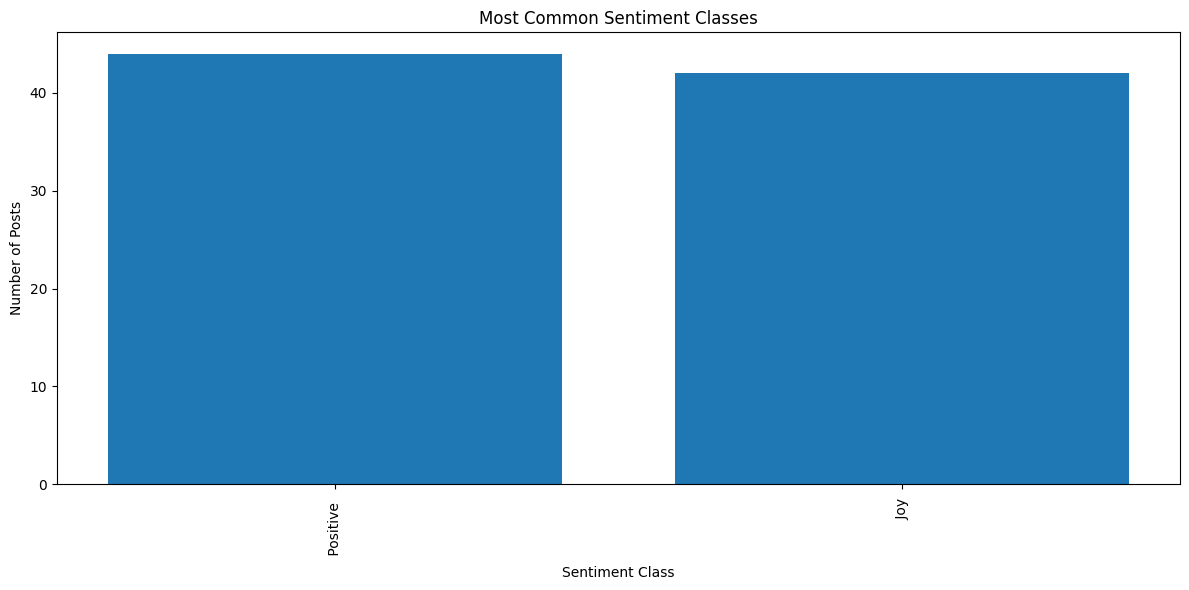

In [61]:
# Identify Most Common Sentiment Classes
top_sentiments = (
    df_sentiment['Sentiment']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_sentiments.index,
    top_sentiments.values
)

plt.title('Most Common Sentiment Classes')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Posts')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

***Interpretation:*** 'Positive' sentiment classes occurred most often in the test set.

### Topic Modeling Via Latent Dirichlet Allocation (LDA)

In [62]:
# Import Additional Libraries
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [63]:
# Create a copy containing the columns needed for topic modeling
df_topics = df.copy()


# Function to clean the post text
def clean_text(text):
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtag symbols
    text = re.sub(r'#', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# Apply the cleaning function
df_topics['Clean_Text'] = (
    df_topics['Text']
    .apply(clean_text)
)


# Check that the new column was created
print(df_topics.columns.tolist())

display(
    df_topics[
        ['Text', 'Platform', 'Clean_Text']
    ].head()
)

['Text', 'Sentiment', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Year', 'Month', 'Day', 'Hour', 'Engagement', 'Post_Length', 'Hashtag_Count', 'High_Engagement', 'Clean_Text']


,Text,Platform,Clean_Text
0,Enjoying a beautiful day at the park! ...,Twitter,enjoying a beautiful day at the park
1,Traffic was terrible this morning. ...,Twitter,traffic was terrible this morning
2,Just finished an amazing workout! 💪 ...,Instagram,just finished an amazing workout
3,Excited about the upcoming weekend getaway! ...,Facebook,excited about the upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,Instagram,trying out a new recipe for dinner tonight


In [64]:
# Perform LDA Separately for Each Platform

# Number of topics
n_topics = 5

platform_results = {}

for platform in df_topics['Platform'].unique():
    
    print('\n' + '=' * 60)
    print('PLATFORM:', platform)
    print('=' * 60)
    
    # Select posts for the current platform
    platform_data = df_topics[
        df_topics['Platform'] == platform
    ].copy()
    
    # Create document-term matrix
    vectorizer = CountVectorizer(
        stop_words='english',
        min_df=2,
        max_df=0.95
    )
    
    document_term_matrix = vectorizer.fit_transform(
        platform_data['Clean_Text']
    )
    
    # Create LDA model
    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch'
    )
    
    # Train the model
    lda_model.fit(document_term_matrix)
    
    # Store the results
    platform_results[platform] = {
        'data': platform_data,
        'vectorizer': vectorizer,
        'document_term_matrix': document_term_matrix,
        'lda_model': lda_model
    }
    
    print('Number of posts:', len(platform_data))
    print(
        'Number of words:',
        len(vectorizer.get_feature_names_out())
    )


PLATFORM: Twitter
Number of posts: 243
Number of words: 355

PLATFORM: Instagram
Number of posts: 258
Number of words: 427

PLATFORM: Facebook
Number of posts: 231
Number of words: 341


***Interpretation:***
- Twitter: Has 243 posts in the dataset. When broken down, 355 words were produced.
- Instagram: Has 258 posts in the dataset. When broken down, 427 words were produced.
- Facebook: Has 231 posts in the dataset. When broken down, 341 words were produced.

In [65]:
# Display Most Important Words Per Topic
for platform, results in platform_results.items():
    
    print('\n' + '=' * 70)
    print('PLATFORM:', platform)
    print('=' * 70)
    
    lda_model = results['lda_model']
    vectorizer = results['vectorizer']
    
    feature_names = vectorizer.get_feature_names_out()
    
    for topic_number, topic in enumerate(
        lda_model.components_
    ):
        
        top_word_indices = topic.argsort()[
            :-11:-1
        ]
        
        top_words = [
            feature_names[i]
            for i in top_word_indices
        ]
        
        print(
            f'\nTopic {topic_number + 1}:'
        )
        
        print(
            ', '.join(top_words)
        )


PLATFORM: Twitter

Topic 1:
dreams, waves, project, historical, anticipation, successfully, creating, hopeful, inspiration, determination

Topic 2:
new, night, beauty, journey, dreams, life, sky, just, spirit, possibilities

Topic 3:
like, feeling, creativity, shattered, day, dance, memories, excitement, sense, sky

Topic 4:
world, school, moment, cup, emotions, challenging, community, garden, day, experiencing

Topic 5:
art, finding, success, challenges, achievement, whispers, symphony, life, ancient, peaks

PLATFORM: Instagram

Topic 1:
new, day, time, book, evening, capturing, learning, trying, exploring, level

Topic 2:
like, canvas, art, world, joy, laughter, loved, confidence, nature, life

Topic 3:
life, emotional, moments, lost, excitement, movie, optimism, hopeful, joy, air

Topic 4:
old, new, emotions, night, surprise, heart, friend, friends, colors, feeling

Topic 5:
nature, soul, vibes, echoes, heart, tears, friends, solitude, family, feeling

PLATFORM: Facebook

Topic 1:


In [66]:
# Create A Topic-Word Table
topic_words = []

for platform, results in platform_results.items():
    
    lda_model = results['lda_model']
    vectorizer = results['vectorizer']
    
    feature_names = vectorizer.get_feature_names_out()
    
    for topic_number, topic in enumerate(
        lda_model.components_
    ):
        
        top_word_indices = topic.argsort()[
            :-11:-1
        ]
        
        top_words = [
            feature_names[i]
            for i in top_word_indices
        ]
        
        topic_words.append({
            'Platform': platform,
            'Topic': topic_number + 1,
            'Top_Words': ', '.join(top_words)
        })

topic_words_df = pd.DataFrame(topic_words)

display(topic_words_df)

,Platform,Topic,Top_Words
0,Twitter,1,"dreams, waves, project, historical, anticipati..."
1,Twitter,2,"new, night, beauty, journey, dreams, life, sky..."
2,Twitter,3,"like, feeling, creativity, shattered, day, dan..."
3,Twitter,4,"world, school, moment, cup, emotions, challeng..."
4,Twitter,5,"art, finding, success, challenges, achievement..."
5,Instagram,1,"new, day, time, book, evening, capturing, lear..."
6,Instagram,2,"like, canvas, art, world, joy, laughter, loved..."
7,Instagram,3,"life, emotional, moments, lost, excitement, mo..."
8,Instagram,4,"old, new, emotions, night, surprise, heart, fr..."
9,Instagram,5,"nature, soul, vibes, echoes, heart, tears, fri..."


In [67]:
# Determine the Dominant Topic for Each Post
for platform, results in platform_results.items():
    
    platform_data = results['data']
    document_term_matrix = results['document_term_matrix']
    lda_model = results['lda_model']
    
    # Calculate topic probabilities
    topic_probabilities = lda_model.transform(
        document_term_matrix
    )
    
    # Find the topic with the highest probability
    dominant_topics = (
        topic_probabilities.argmax(axis=1) + 1
    )
    
    # Add dominant topic to the platform data
    platform_data['Dominant_Topic'] = dominant_topics
    
    # Save the updated data
    platform_results[platform]['data'] = platform_data

In [68]:
# Examine Topic Distribution By Platform
topic_distribution = []

for platform, results in platform_results.items():
    
    platform_data = results['data']
    
    counts = (
        platform_data['Dominant_Topic']
        .value_counts()
        .sort_index()
    )
    
    for topic, count in counts.items():
        
        topic_distribution.append({
            'Platform': platform,
            'Topic': topic,
            'Number_of_Posts': count
        })

topic_distribution_df = pd.DataFrame(
    topic_distribution
)

display(topic_distribution_df)

,Platform,Topic,Number_of_Posts
0,Twitter,1,42
1,Twitter,2,51
2,Twitter,3,51
3,Twitter,4,51
4,Twitter,5,48
5,Instagram,1,59
6,Instagram,2,57
7,Instagram,3,46
8,Instagram,4,50
9,Instagram,5,46


In [69]:
# Calculate Topic Percentages
topic_distribution_df['Percentage'] = (
    topic_distribution_df
    .groupby('Platform')['Number_of_Posts']
    .transform(
        lambda x: x / x.sum() * 100
    )
)

topic_distribution_df['Percentage'] = (
    topic_distribution_df['Percentage']
    .round(2)
)

display(topic_distribution_df)

,Platform,Topic,Number_of_Posts,Percentage
0,Twitter,1,42,17.28
1,Twitter,2,51,20.99
2,Twitter,3,51,20.99
3,Twitter,4,51,20.99
4,Twitter,5,48,19.75
5,Instagram,1,59,22.87
6,Instagram,2,57,22.09
7,Instagram,3,46,17.83
8,Instagram,4,50,19.38
9,Instagram,5,46,17.83


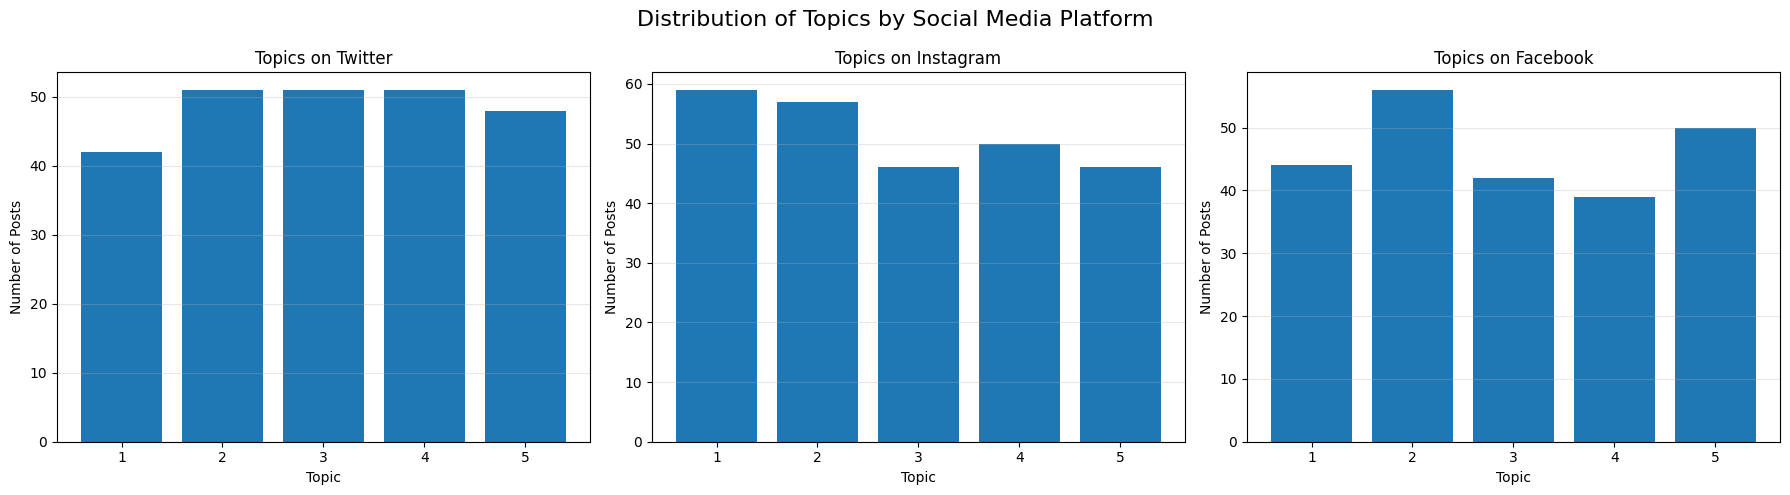

In [70]:
# Visualize Topic Distribution By Platform
platforms = topic_distribution_df[
    'Platform'
].unique()

fig, axes = plt.subplots(
    1,
    len(platforms),
    figsize=(18, 5)
)

if len(platforms) == 1:
    axes = [axes]

for i, platform in enumerate(platforms):
    
    data = topic_distribution_df[
        topic_distribution_df['Platform'] == platform
    ]
    
    axes[i].bar(
        data['Topic'].astype(str),
        data['Number_of_Posts']
    )
    
    axes[i].set_title(
        f'Topics on {platform}'
    )
    
    axes[i].set_xlabel('Topic')
    axes[i].set_ylabel('Number of Posts')
    
    axes[i].grid(
        axis='y',
        alpha=0.3
    )

plt.suptitle(
    'Distribution of Topics by Social Media Platform',
    fontsize=16
)

plt.tight_layout()
plt.show()

***Interpretation:*** 
The topic distribution per platform is as follows: 
- Twitter: The 3 most dominant topics were Topic 2, 3 and 4. 
- Instagram: The most dominant topic was Topic 1. 
- Facebook: The most dominant topic was Topic 2.
Therefore, posts including words associated with these topics are the most dominant in the dataset. Moreover, social media advertisers may include words from these topics in their ad posts to optimize audience reach. 